In [1]:
from google.colab import drive
drive.mount('/content/drive')

import glob
hits = glob.glob('/content/drive/MyDrive/DATASCI 281*/BDD100k DATA')
print(hits)
BASE = hits[0]
print("BASE =", BASE)

Mounted at /content/drive
['/content/drive/MyDrive/DATASCI 281 Group Project/BDD100k DATA']
BASE = /content/drive/MyDrive/DATASCI 281 Group Project/BDD100k DATA


In [3]:
import numpy as np
data = np.load(f'{BASE}/features_dev.npz', allow_pickle=True)
X_hsv, X_hog, X_lbp, X_resnet, y = data['hsv'], data['hog'], data['lbp'], data['resnet'], data['y']

print(X_hsv.shape, X_hog.shape, X_lbp.shape, X_resnet.shape, y.shape)

(4217, 144) (4217, 4320) (4217, 10) (4217, 2048) (4217,)


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import glob, os
hits = glob.glob('/content/drive/MyDrive/DATASCI 281*/BDD100k DATA')
print(hits)
BASE = hits[0]
print("BASE =", BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['/content/drive/MyDrive/DATASCI 281 Group Project/BDD100k DATA']
BASE = /content/drive/MyDrive/DATASCI 281 Group Project/BDD100k DATA


In [5]:
import pandas as pd
df = pd.read_csv(f'{BASE}/scene_manifest.csv')
print(df['scene'].value_counts())

CAP = 1200
sample = (df.groupby('scene', group_keys=False)
            .apply(lambda g: g.sample(min(len(g), CAP), random_state=42))
            .reset_index(drop=True))
print(sample['scene'].value_counts())
print(len(sample), "images in dev sample")

scene
city street     49693
highway         19913
residential      9358
parking lot       427
tunnel            156
gas stations       34
Name: count, dtype: int64
scene
city street     1200
highway         1200
residential     1200
parking lot      427
tunnel           156
gas stations      34
Name: count, dtype: int64
4217 images in dev sample


/tmp/ipykernel_2441/1537375444.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), CAP), random_state=42))


In [13]:
missing = sum(not os.path.exists(p) for p in sample['img_path'].head(20))
print(f"{missing}/20 checked — should be 0")

0/20 checked — should be 0


In [11]:
!ls /content/data

100k


In [7]:
!unzip -q "{BASE}/bdd100k_images_100k.zip" -d /content/data

In [12]:
import os
os.rename('/content/data/100k', '/content/data/100k_images')

In [14]:
import cv2
import numpy as np

IMG_W, IMG_H = 256, 144

def load_img(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (IMG_W, IMG_H))

def feat_global_rgb(img, bins=16):
    """Whole-image RGB histogram — one histogram per channel, no spatial split."""
    feats = []
    for ch in range(3):
        hist = cv2.calcHist([img], [ch], None, [bins], [0, 256]).flatten()
        feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 ch × 16 bins = 48 dims

def feat_global_hsv(img, bins=16):
    """Whole-image HSV histogram — one histogram per channel, no spatial split."""
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    feats = []
    for ch in range(3):
        hist = cv2.calcHist([hsv], [ch], None, [bins], [0, 256]).flatten()
        feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 ch × 16 bins = 48 dims

def feat_region_rgb(img, bins=16):
    """Region-wise RGB: top/middle/bottom bands, for comparison against global."""
    h = img.shape[0]
    bands = [img[:h//3], img[h//3:2*h//3], img[2*h//3:]]
    feats = []
    for band in bands:
        for ch in range(3):
            hist = cv2.calcHist([band], [ch], None, [bins], [0, 256]).flatten()
            feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 bands × 3 ch × 16 bins = 144 dims

def feat_region_hsv(img, bins=16):
    """Region-wise HSV — same as teammate's feat_hsv_regions."""
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h = img.shape[0]
    bands = [hsv[:h//3], hsv[h//3:2*h//3], hsv[2*h//3:]]
    feats = []
    for band in bands:
        for ch in range(3):
            hist = cv2.calcHist([band], [ch], None, [bins], [0, 256]).flatten()
            feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 bands × 3 ch × 16 bins = 144 dims

In [15]:
import time
from tqdm import tqdm

extractors = {
    'global_rgb': feat_global_rgb,
    'global_hsv': feat_global_hsv,
    'region_rgb': feat_region_rgb,
    'region_hsv': feat_region_hsv,
}

imgs_cache = [load_img(p) for p in tqdm(sample['img_path'], desc='loading images')]

results = {}
for name, fn in extractors.items():
    t0 = time.time()
    X = np.array([fn(img) for img in imgs_cache])
    elapsed = time.time() - t0
    results[name] = {'X': X, 'time_sec': elapsed}
    print(f"{name}: shape={X.shape}, time={elapsed:.1f}s "
          f"({elapsed/len(imgs_cache)*1000:.2f} ms/image)")

y = sample['scene'].values

loading images: 100%|██████████| 4217/4217 [00:31<00:00, 135.66it/s]


global_rgb: shape=(4217, 48), time=0.6s (0.14 ms/image)
global_hsv: shape=(4217, 48), time=1.2s (0.29 ms/image)
region_rgb: shape=(4217, 144), time=0.8s (0.19 ms/image)
region_hsv: shape=(4217, 144), time=1.9s (0.46 ms/image)


In [16]:
np.savez(f'{BASE}/features_color_ablation.npz',
         global_rgb=results['global_rgb']['X'],
         global_hsv=results['global_hsv']['X'],
         region_rgb=results['region_rgb']['X'],
         region_hsv=results['region_hsv']['X'],
         y=y)

timing_df = pd.DataFrame({
    'feature': list(results.keys()),
    'dims': [results[k]['X'].shape[1] for k in results],
    'total_time_sec': [round(results[k]['time_sec'], 2) for k in results],
    'ms_per_image': [round(results[k]['time_sec']/len(imgs_cache)*1000, 3) for k in results],
})
timing_df.to_csv(f'{BASE}/color_ablation_timing.csv', index=False)
print(timing_df)

      feature  dims  total_time_sec  ms_per_image
0  global_rgb    48            0.58         0.137
1  global_hsv    48            1.24         0.293
2  region_rgb   144            0.81         0.193
3  region_hsv   144            1.92         0.456


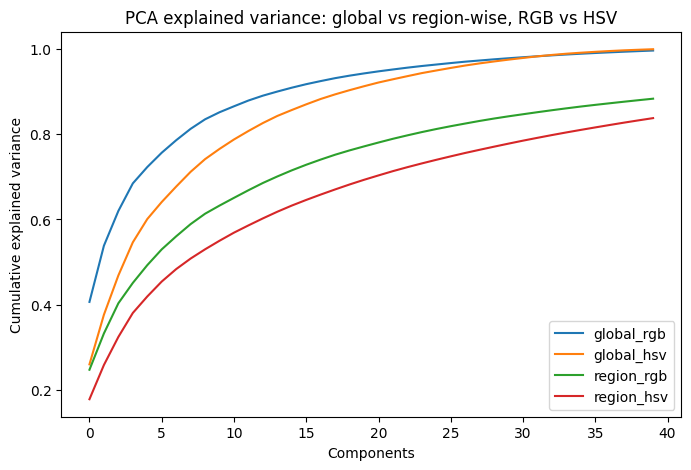

In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.figure(figsize=(8, 5))
for name in extractors:
    Xs = StandardScaler().fit_transform(results[name]['X'])
    pca = PCA(n_components=min(40, Xs.shape[1])).fit(Xs)
    plt.plot(np.cumsum(pca.explained_variance_ratio_), label=name)
plt.xlabel('Components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.title('PCA explained variance: global vs region-wise, RGB vs HSV')
plt.show()

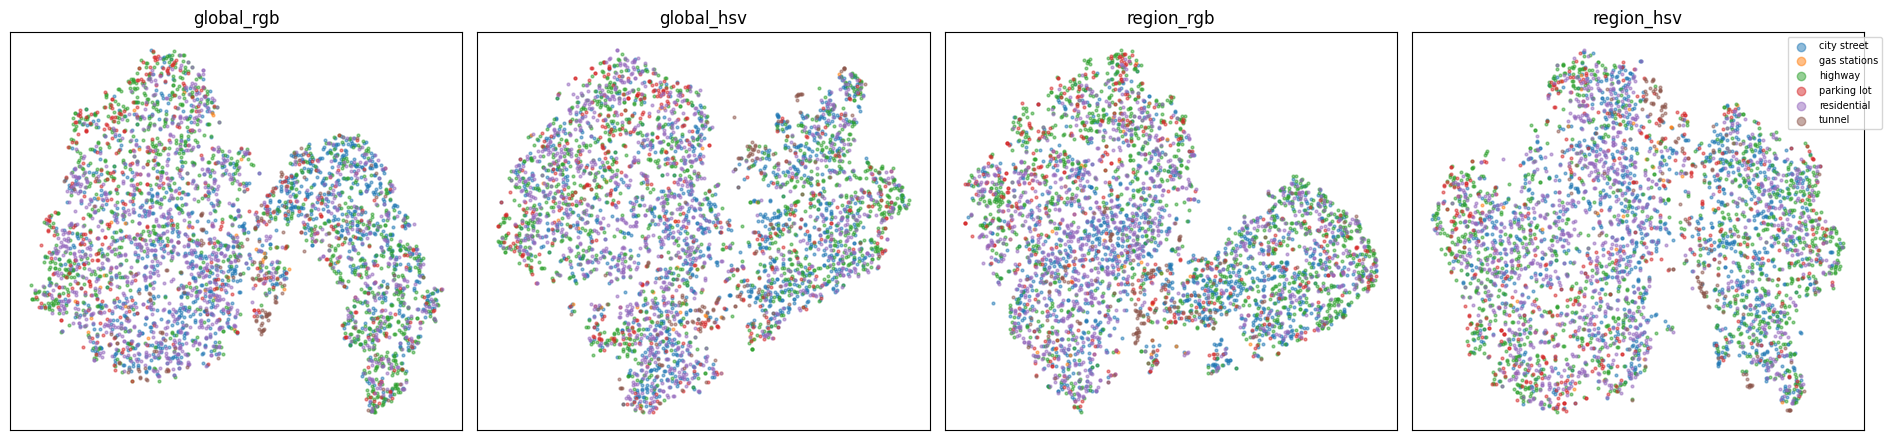

In [18]:
from sklearn.manifold import TSNE

classes = sorted(sample['scene'].unique())
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, name in zip(axes, extractors):
    Xs = StandardScaler().fit_transform(results[name]['X'])
    Xp = PCA(n_components=min(30, Xs.shape[1])).fit_transform(Xs)
    emb = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(Xp)
    for c in classes:
        m = y == c
        ax.scatter(emb[m, 0], emb[m, 1], s=4, alpha=0.5, label=c)
    ax.set_title(name)
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(markerscale=3, fontsize=7, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

| Feature | Type | Dims | What it captures |
|---|---|---|---|
| Global RGB histogram | Simple (ablation) | 48 | Whole-image color distribution, no spatial info. Fast, low complexity — highest PCA compressibility of the four variants. |
| Global HSV histogram | Simple (ablation) | 48 | Whole-image color distribution with brightness/hue separated. Less redundant than RGB (channels less correlated), so slightly less compressible. |
| Region-wise RGB histogram | Simple (ablation) | 144 | Top/middle/bottom band color distribution, no hue/brightness separation. Captures sky–structure–road stratification but with RGB's redundancy. |
| Region-wise HSV histogram | Simple (primary) | 144 | Top/middle/bottom band HSV distribution — the feature used in the main pipeline. Highest information density (least compressible), used to justify this as the color feature of choice despite weak standalone t-SNE separability. |

Color histogram ablation: global vs. region-wise, RGB vs. HSV. To validate the design choice of region-wise HSV histograms over simpler alternatives, we extracted four color-histogram variants on the same dev sample (global RGB, global HSV, region-wise RGB, region-wise HSV) and compared them via PCA and t-SNE. PCA explained-variance curves show global histograms are substantially more compressible than region-wise ones (reaching ~100% cumulative variance by ~35 components vs. ~85-88% for region-wise at the same budget), and RGB compresses faster than HSV within each grouping. This is consistent with expectation rather than a weakness: RGB's channels are correlated (brightness shifts move R, G, and B together), so early components capture most of its variance, while HSV's explicit separation of hue from brightness — and region-wise splitting's deliberate capture of distinct top/middle/bottom information — spread real signal across more dimensions instead of compressing away information. t-SNE visualization, however, shows all four variants produce heavily overlapping class clusters, with none approaching the separation seen in the ResNet embeddings. The clearest partial separation appears between city street and highway (consistent with their differing openness and color composition) and small tunnel sub-clusters (consistent with tunnels' distinctive dark, artificially-lit color signature), while residential, parking lot, and gas stations show essentially no visual separation in any variant — likely compounded by the severe sample scarcity in the latter two classes. Region-wise histograms did not show a clear visual separability advantage over global histograms in 2D t-SNE space despite carrying more non-redundant information per PCA. This confirms that color alone provides weak-to-moderate signal for scene classification — sufficient for some open-vs-enclosed distinctions but not for the finer-grained classes — reinforcing the motivation for combining color features with structural (HOG) and learned (ResNet) representations rather than relying on color histograms in isolation.